> ⚠️ **Historical notebook — predates the reworked pipeline.**
>
> This notebook was written against the original codebase and has not been updated for the changes merged in PRs #1–#5: cash-ledger backtest NAV, purged walk-forward splits, the lambdarank objective (`--rank-objective`), rank-hold portfolio mode, top-15 default, and the relative-return reporting. Cells may fail or produce results that no longer match the CLI pipeline.
>
> For current usage, see the README and the `train-sp500` / `backtest-sp500` / `predict-sp500` CLIs, plus `scripts/backtest_sweep.py` for strategy grids.

# S&P 500 weekly move exploration

Goal: explore how rare **≥5% gains over the next 10 trading days** are, and build a clean panel (features at `t`, label from `t+1…t+10`).

Run with: `uv run jupyter notebook` or `uv run jupyter lab` from the project root.

In [18]:
from __future__ import annotations

import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 20)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

from pathlib import Path
import sys

for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pyproject.toml").exists():
        sys.path.insert(0, str(_root.resolve()))
        break

from sp500_pit import filter_panel_to_pit, load_sp500_stints, tickers_overlapping_window

START = "2018-01-01"
END = None

## 1. S&P 500 universe (point-in-time)

Universe comes from **[fja05680/sp500](https://github.com/fja05680/sp500)** `sp500_ticker_start_end.csv` (community-maintained, not official S&P). Rows are filtered to membership stints `[start_date, end_date)` after prices are stacked.

In [19]:
SP500_STINTS_URL = (
    "https://raw.githubusercontent.com/fja05680/sp500/master/sp500_ticker_start_end.csv"
)
stints = load_sp500_stints(SP500_STINTS_URL)
tickers = tickers_overlapping_window(stints, START, END)
print(f"Tickers (union of stints overlapping [START, END]): {len(tickers)}")
stints.head()

Tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## 2. Download daily prices (sample first)

Pulling all 500 names on the first run is slow and rate-limit prone. Start with `SAMPLE_N` tickers, then increase.

In [20]:
SAMPLE_N = 1000000  # raise once you're happy with the pipeline

sample = tickers[:SAMPLE_N]
data = yf.download(
    sample,
    start=START,
    end=END,
    group_by="ticker",
    threads=True,
    auto_adjust=True,
    progress=False,
)

# With auto_adjust=True, yfinance does not return "Adj Close" — OHLC are already adjusted; use "Close".
# With auto_adjust=False, prefer "Adj Close" for total return.
def wide_adj_close(raw: pd.DataFrame) -> pd.DataFrame:
    if isinstance(raw.columns, pd.MultiIndex):
        fields = set(raw.columns.get_level_values(-1))
        price_col = "Adj Close" if "Adj Close" in fields else "Close"
        return raw.xs(price_col, axis=1, level=-1).sort_index()
    if "Adj Close" in raw.columns:
        return raw[["Adj Close"]].sort_index()
    return raw[["Close"]].sort_index()


adj_close = wide_adj_close(data)
adj_close.tail()

Ticker,SOLV,BIIB,MTD,CSGP,NWS,SRE,RCL,DE,SHW,TFC,...,L,ACGL,PG,DHR,FISV,REG,ZBH,LEN,VRSN,F
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-06,63.250000,172.339996,1266.630005,41.18,28.139999,98.010002,275.700012,575.090027,316.390015,47.639999,...,107.769997,96.790001,142.770004,192.119995,56.320000,76.629997,91.000000,88.570000,274.510010,11.61
2026-04-07,62.490002,175.610001,1270.000000,39.48,28.100000,98.459999,267.709991,576.000000,313.959991,47.830002,...,107.919998,96.919998,141.300003,191.009995,55.320000,77.330002,91.400002,85.620003,274.750000,11.52
2026-04-08,65.250000,179.899994,1322.760010,38.82,28.700001,98.879997,279.260010,609.320007,335.670013,49.290001,...,109.790001,98.599998,144.899994,196.190002,56.630001,77.860001,93.010002,88.629997,270.899994,12.18
2026-04-09,66.180000,177.110001,1335.000000,37.32,28.400000,99.750000,275.890015,618.000000,335.730011,50.480000,...,110.879997,98.839996,146.660004,192.990005,56.410000,78.349998,93.029999,88.930000,269.880005,12.24
2026-04-10,65.790001,172.970001,1325.010010,36.48,28.260000,98.820000,276.940002,605.000000,336.109985,49.599998,...,109.470001,95.970001,145.160004,189.610001,56.090000,78.400002,93.120003,88.970001,259.779999,12.13


## 3. Forward 5-trading-day return and label

For each row (date) per ticker: **close-to-close** return from that close to the close **10 trading sessions later**.
Label `target_5pct` = 1 if forward return ≥ 5%.

In [21]:
HORIZON = 10
THRESHOLD = 0.05

long = adj_close.stack(future_stack=True).rename("adj_close").reset_index()
long.columns = ["date", "ticker", "adj_close"]
long = long.sort_values(["ticker", "date"])

long["fwd_ret_10d"] = (
    long.groupby("ticker", group_keys=False)["adj_close"].transform(
        lambda s: s.shift(-HORIZON) / s - 1.0
    )
)
long["target_5pct"] = (long["fwd_ret_10d"] >= THRESHOLD).astype("int8")

labeled = long.dropna(subset=["fwd_ret_10d"])
labeled = filter_panel_to_pit(labeled, stints)
labeled.head(10)

,date,ticker,adj_close,fwd_ret_10d,target_5pct
267,2018-01-02,A,63.522766,0.065977,1
770,2018-01-03,A,65.139023,0.041402,0
1273,2018-01-04,A,64.650398,0.062064,1
1776,2018-01-05,A,65.684036,0.051216,1
2279,2018-01-08,A,65.824982,0.048394,0
2782,2018-01-09,A,67.441254,0.025219,0
3285,2018-01-10,A,66.520378,0.043368,0
3788,2018-01-11,A,66.529762,0.056780,1
4291,2018-01-12,A,67.403671,0.039035,0
4794,2018-01-16,A,66.933830,0.024708,0


## 4. How rare is +5% / 10 sessions?

Expect **class imbalance** (many more 0s than 1s) — that’s what makes ranking and precision@k matter more than raw accuracy.

Positive rate (>= 5% in 10 sessions): 19.6771%


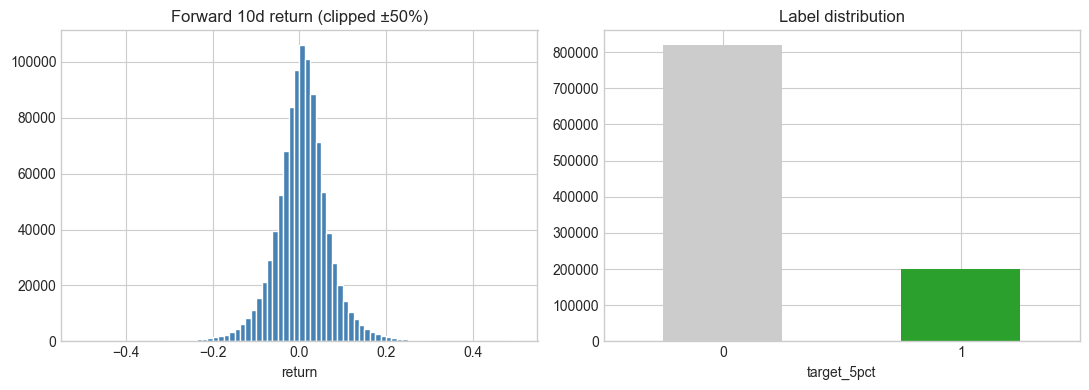

In [22]:
pos_rate = labeled["target_5pct"].mean()
print(f"Positive rate (>= {THRESHOLD:.0%} in {HORIZON} sessions): {pos_rate:.4%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labeled["fwd_ret_10d"].clip(-0.5, 0.5).hist(bins=80, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].set_title("Forward 10d return (clipped ±50%)")
ax[0].set_xlabel("return")
labeled["target_5pct"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color=["#ccc", "#2ca02c"])
ax[1].set_title("Label distribution")
ax[1].set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# ── Cell: Feature Engineering ──────────────────────────────────────────────
# All features use ONLY information available at time `t` to avoid lookahead bias.

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:  long-format DataFrame with columns [date, ticker, adj_close]
            sorted by [ticker, date].
    Output: same DataFrame with new feature columns added.
    """
    g = df.groupby("ticker", group_keys=False)["adj_close"]

    # ── Past returns ──────────────────────────────────────────────────────
    for lag in [1, 5, 10, 21]:
        df[f"ret_{lag}d"] = g.transform(lambda s: s.pct_change(lag))

    # ── Momentum (21-day return minus 5-day, avoids short-term reversal) ──
    df["momentum"] = df["ret_21d"] - df["ret_5d"]

    # ── Volatility (rolling std of daily returns) ─────────────────────────
    daily_ret = g.transform(lambda s: s.pct_change())
    df["vol_10d"] = daily_ret.groupby(df["ticker"]).transform(
        lambda s: s.rolling(10).std()
    )
    df["vol_21d"] = daily_ret.groupby(df["ticker"]).transform(
        lambda s: s.rolling(21).std()
    )

    # ── Volume z-score (requires volume data — see note below) ────────────
    # Skipping for now if not available; add when you pull volume from yfinance

    # ── RSI (14-day) ──────────────────────────────────────────────────────
    def rsi(s: pd.Series, window: int = 14) -> pd.Series:
        delta = s.diff()
        gain = delta.clip(lower=0).rolling(window).mean()
        loss = (-delta.clip(upper=0)).rolling(window).mean()
        rs = gain / loss.replace(0, np.nan)
        return 100 - 100 / (1 + rs)

    df["rsi_14"] = g.transform(rsi)

    # ── Price relative to rolling mean (mean-reversion signal) ───────────
    df["price_vs_ma20"] = g.transform(lambda s: s / s.rolling(20).mean() - 1)
    df["price_vs_ma50"] = g.transform(lambda s: s / s.rolling(50).mean() - 1)

    # ── Bollinger Band position ───────────────────────────────────────────
    def bb_position(s: pd.Series, window: int = 20) -> pd.Series:
        ma = s.rolling(window).mean()
        std = s.rolling(window).std()
        upper = ma + 2 * std
        lower = ma - 2 * std
        return (s - lower) / (upper - lower + 1e-9)

    df["bb_pos"] = g.transform(bb_position)

    return df


features = add_features(labeled.copy())

FEATURE_COLS = [
    "ret_1d", "ret_5d", "ret_10d", "ret_21d",
    "momentum", "vol_10d", "vol_21d",
    "rsi_14", "price_vs_ma20", "price_vs_ma50", "bb_pos",
]

# Drop rows with NaN in any feature (warm-up period for rolling windows)
features = features.dropna(subset=FEATURE_COLS + ["target_5pct"])
print(f"Panel shape: {features.shape}")
print(f"Positive rate after feature engineering: {features['target_5pct'].mean():.4%}")
features[FEATURE_COLS].describe()

Panel shape: (994583, 16)
Positive rate after feature engineering: 19.7403%


,ret_1d,ret_5d,ret_10d,ret_21d,momentum,vol_10d,vol_21d,rsi_14,price_vs_ma20,price_vs_ma50,bb_pos
count,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000,994583.000000
mean,0.000654,0.003228,0.006470,0.013898,0.010670,0.018563,0.019170,52.664831,0.004614,0.012224,0.543490
std,0.022451,0.049042,0.068026,0.099227,0.087860,0.012790,0.011752,16.956138,0.053368,0.084332,0.324961
min,-0.538647,-0.681183,-0.860719,-0.871677,-1.751312,0.000000,0.001001,0.000000,-0.810732,-0.855698,-0.562132
25%,-0.009124,-0.020154,-0.027730,-0.038776,-0.034156,0.011008,0.012126,40.577433,-0.021497,-0.031801,0.282529
50%,0.000806,0.003607,0.006774,0.012929,0.010346,0.015310,0.016201,52.849553,0.006299,0.014319,0.575174
75%,0.010517,0.026473,0.040249,0.063671,0.053767,0.021877,0.022266,64.953249,0.032116,0.057802,0.807558
max,0.745933,1.192308,1.796854,2.184572,2.122220,0.319619,0.224650,99.974963,0.953609,1.581349,1.539633


In [24]:
# ── Cell: Time-based split ──────────────────────────────────────────────────
# CRITICAL: never use random splits for time series — it leaks future information.

TRAIN_END = "2022-12-31"
TEST_START = "2023-01-01"

train = features[features["date"] <= TRAIN_END]
test  = features[features["date"] >= TEST_START]

X_train, y_train = train[FEATURE_COLS], train["target_5pct"]
X_test,  y_test  = test[FEATURE_COLS],  test["target_5pct"]

print(f"Train: {X_train.shape} | Positives: {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.mean():.4%}")

Train: (589660, 11) | Positives: 20.2261%
Test:  (404923, 11)  | Positives: 19.0330%


In [26]:
# ── Cell: LightGBM model ────────────────────────────────────────────────────
# uv add lightgbm scikit-learn  (if not already installed)

import lightgbm as lgb
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)

# scale_pos_weight handles class imbalance: ratio of negatives to positives
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight: {spw:.1f}")

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

scale_pos_weight: 3.9
[LightGBM] [Info] Number of positive: 119265, number of negative: 470395
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 589660, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202261 -> initscore=-1.372225
[LightGBM] [Info] Start training from score -1.372225
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.486223


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


PR-AUC  : 0.2722  (baseline = 0.1903)
ROC-AUC : 0.6166  (baseline = 0.5000)

Mean weekly Precision@10 : 0.3917
Baseline (random pick)   : 0.1903


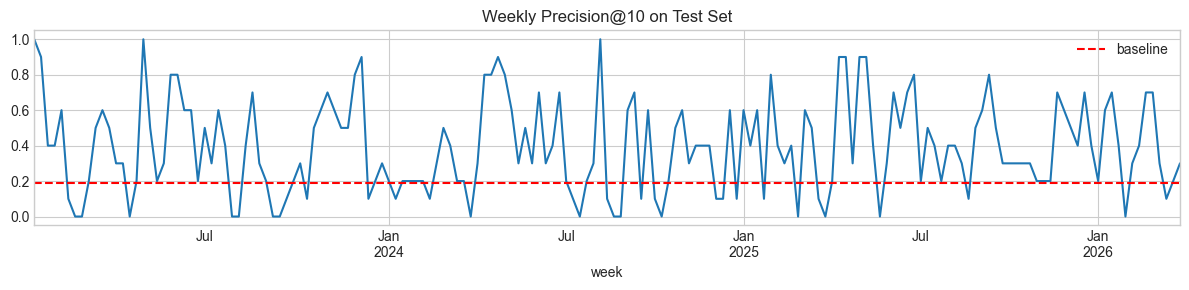

In [27]:
# ── Cell: Evaluation ────────────────────────────────────────────────────────
# With heavy class imbalance, accuracy is meaningless.
# We care about:
#   1. PR-AUC: overall ranking quality for the positive class
#   2. Precision@k: when we pick the top-k predictions per week, how often are we right?

y_prob = model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"PR-AUC  : {pr_auc:.4f}  (baseline = {y_test.mean():.4f})")
print(f"ROC-AUC : {roc_auc:.4f}  (baseline = 0.5000)")

# ── Precision@k (the realistic trading metric) ────────────────────────────
def precision_at_k(y_true, y_scores, k: int) -> float:
    """Of the top-k ranked predictions, what fraction are truly positive?"""
    top_k_idx = np.argsort(y_scores)[-k:]
    return y_true.iloc[top_k_idx].mean()

test_scored = test.copy()
test_scored["prob"] = y_prob

# Simulate: every week, pick the top-10 candidates and check precision
weekly_precision = (
    test_scored
    .assign(week=lambda df: pd.to_datetime(df["date"]).dt.to_period("W"))
    .groupby("week")
    .apply(lambda g: precision_at_k(g["target_5pct"], g["prob"], k=10))
)

print(f"\nMean weekly Precision@10 : {weekly_precision.mean():.4f}")
print(f"Baseline (random pick)   : {y_test.mean():.4f}")

weekly_precision.plot(figsize=(12, 3), title="Weekly Precision@10 on Test Set")
plt.axhline(y_test.mean(), color="red", linestyle="--", label="baseline")
plt.legend()
plt.tight_layout()
plt.show()

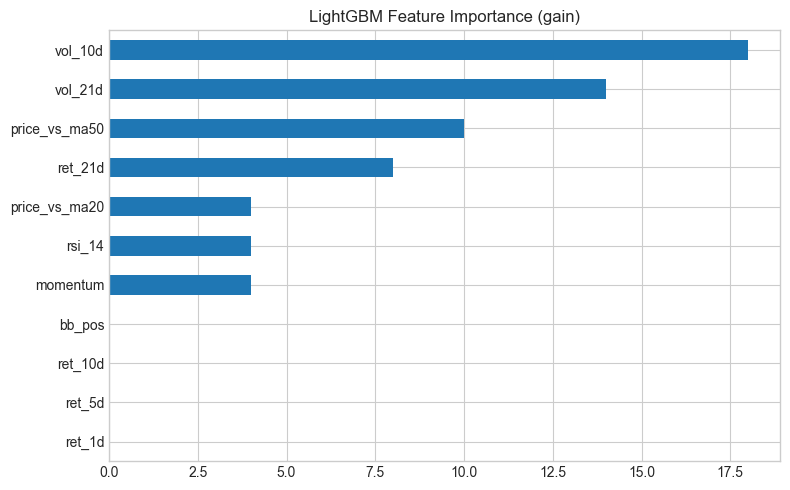

In [28]:
# ── Cell: Feature importance ─────────────────────────────────────────────────
importance = pd.Series(
    model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

importance.plot(kind="barh", figsize=(8, 5), title="LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()

## Next steps (when you’re ready)

- Add **features** known at `date` only (past returns, vol, volume z-scores).
- Use **time-based splits**; measure **precision@k** and PR-AUC, not plain accuracy.
- Swap the stint CSV URL for a **vendor feed** (e.g. WRDS/Compustat) if you need official S&P history.